<a href="https://colab.research.google.com/github/pablocelva/proyecto-inmersion-ia/blob/main/Inmersi%C3%B3n_Agentes_de_IA_Alura_Clase_2_%2B_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q google-genai

In [ ]:
from google.colab import userdata
import os

os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')

In [ ]:
from google import genai

cliente = genai.Client()

In [ ]:
respuesta = cliente.models.generate_content(
    model="gemini-2.5-flash",
    contents="Cuál es la capital y la ciudad más grande de Turquía?"
)

print(respuesta.text)

La capital de Turquía es **Ankara**.

La ciudad más grande de Turquía es **Estambul**.


In [ ]:
from google.colab import files

os.makedirs("PDFs", exist_ok=True)
uploader = files.upload()

for archivo in uploader.keys():
  os.rename(archivo, f"PDFs/{archivo}")

Saving Carrarurquia_Reporte_Q1_2025.pdf to Carrarurquia_Reporte_Q1_2025.pdf
Saving Carrarurquia_Reporte_Q2_2025.pdf to Carrarurquia_Reporte_Q2_2025.pdf
Saving Carrarurquia_Reporte_Q3_2025.pdf to Carrarurquia_Reporte_Q3_2025.pdf
Saving Carrarurquia_Reporte_Q4_2025.pdf to Carrarurquia_Reporte_Q4_2025.pdf


In [ ]:
!pip install -q langchain-community pypdf

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

In [ ]:
documentos = []

for archivo2 in os.listdir("PDFs"):
  ruta = os.path.join("PDFs", archivo2)
  loader = PyPDFLoader(ruta)
  paginas = loader.load()
  documentos.extend(paginas)

In [ ]:
documentos[0]

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q2 2025', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q2_2025.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Carrarurquía\nReporte trimestral Q2 2025 (ficticio)\nPeriodo: 01/04/2025 - 30/06/2025\nMoneda: USD\n1\n Carrarurquía\n Reporte trimestral Q2 2025 · Viajes a Turquía (ficticio)\n Periodo: 01/04/2025 - 30/06/2025\n Moneda de referencia: dólares estadounidenses (USD)\nEste documento presenta resultados y aprendizajes ficticios del trimestre para Carrarurquía, una\nempresa de viajes especializada en experiencias en Turquía. Los datos, cifras y testimonios han sido\ncreados con fines demostrativos y no representan operaciones reales.\n Edición: Julio de 2025')

In [ ]:
len(documentos)

60

In [ ]:
!pip install -q langchain-text-splitters

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

divisor = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=40,
    separators=["\n\n", "\n", ". ", " ", ""]
)

fragmentos = divisor.split_documents(documentos)

In [ ]:
fragmentos[67]

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:30:27+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:30:27+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q1_2025.pdf', 'total_pages': 15, 'page': 8, 'page_label': '9'}, page_content='5. Operaciones y calidad\nEntrega del viaje\nEn Q1 se operaron 68 salidas (grupales y semi-privadas), con un cumplimiento de\nitinerario del 93%. Las incidencias se concentraron en traslados interurbanos en días de\nlluvia y en reprogramaciones por disponibilidad de actividades.\nCadena de suministro y proveedores\nProveedor\nTipo\nRegión\nParticipación de coste\nEvaluación (1-5)\nBosporus DMC\nOperador local')

In [ ]:
!pip install -q langchain-google-genai faiss-cpu

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001"
)

In [ ]:
len(fragmentos)

172

In [ ]:
vectorstore1 = FAISS.from_documents(
    documents=fragmentos[0:89],
    embedding=embeddings
)

In [ ]:
vectorstore2 = FAISS.from_documents(
    documents=fragmentos[90:],
    embedding=embeddings
)

In [ ]:
vectorstore1.index.reconstruct(0)

array([-0.00143831,  0.00889298,  0.01531782, ...,  0.01553657,
       -0.00974552, -0.02190461], dtype=float32)

In [ ]:
len(vectorstore1.index.reconstruct(0))

3072

In [ ]:
vectorstore1.merge_from(vectorstore2)

In [ ]:
consulta = "Cuál es el paquete de viajes más económico de Carrarurquía?"

resultados = vectorstore1.similarity_search(
    consulta,
    k=7
)

for i in resultados:
  print(i)
  print("\n")

page_content='Carrarurquía
Reporte trimestral Q3 2025 (ficticio)
Periodo: 01/07/2025 - 30/09/2025
Moneda: USD
13
11. Apéndice A: Paquetes y tarifas de referencia
Lista simplificada de precios (USD)
Tarifas ficticias orientativas para paquetes populares. Los importes se muestran por persona en ocupación' metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q3 2025', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q3_2025.pdf', 'total_pages': 15, 'page': 12, 'page_label': '13'}


page_content='Carrarurquía
Reporte trimestral Q4 2025 (ficticio)
Periodo: 01/10/2025 - 31/12/2025
Moneda: USD
13
11. Apéndice A: Paquetes y tarifas de referencia
Lista simplificada de precios (USD)
Tarifas ficticias orientativas para paquetes populares. Los importes se muestran

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2
)

retriever = vectorstore1.as_retriever(
    search_kwargs={"k": 4}
)

In [ ]:
def preguntar_rag(pregunta):
    """Busca contexto relevante en los documentos y genera una respuesta."""
    # Paso 1: Buscar los chunks más relevantes
    docs = retriever.invoke(pregunta)
    contexto = "\n\n---\n\n".join(doc.page_content for doc in docs)

    # Paso 2: Construir el prompt con el contexto encontrado
    prompt = f"""Eres un asistente experto que responde preguntas basándose ÚNICAMENTE
    en el contexto proporcionado. Si la información no está en el contexto,
    di que no tienes suficiente información.

    Contexto: {contexto}

    Pregunta: {pregunta}

    Respuesta:"""

    # Paso 3: Enviar al modelo y devolver la respuesta
    respuesta = llm.invoke(prompt)
    return respuesta.content

In [ ]:
preguntar_rag("Dónde se mantuvo concentrado el mix de productos?")

'El mix de producto se mantuvo concentrado en circuitos combinados (Estambul + Capadocia).'

In [ ]:
preguntar_rag("Cuántos mundiales de fútbol tiene Brasil?")

'No tengo suficiente información en el contexto proporcionado para responder cuántos mundiales de fútbol tiene Brasil.'

In [ ]:
!pip install -q langgraph google-search-results markdown fpdf2

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.6/301.6 kB 6.6 MB/s eta 0:00:00


In [ ]:
os.environ['SERPAPI_API_KEY'] = userdata.get('SERPAPI_API_KEY')

In [ ]:
from langchain_community.utilities import SerpAPIWrapper

buscador = SerpAPIWrapper()

resp = buscador.run("Cuántos atletas turcos fueran a las olimpiadas de invierno 2026?")
resp

'["Turquía está representada en los Juegos Olímpicos de Milán-Cortina d\'Ampezzo 2026 por ocho deportistas, seis hombres y dos mujeres, que compiten en cuatro ...", \'2900. Atletas · 92. Comités Olímpicos Nacionales · 16. Deportes · 116. Eventos de medalla.\', \'Un verdadero terremoto en el mundo del atletismo: Turquía nacionaliza a tres medallistas olímpicos de Jamaica, entre ellos Roje Stona (oro en ...\', \'De los 82 deportistas, 37 debutarán en esta edición de los Juegos. Otros llegan con una trayectoria consolidada, como Faye Thelen, Lindsey Vonn, ...\', \'En los Juegos Olímpicos de 2026, el equipo de EE. UU. tendrá su equipo más grande para los Juegos de Invierno hasta la fecha.\', \'Más de 90 países estarán representados en los Juegos Olímpicos de Milán Cortina 2026. Once de esos equipos son de Latinoamérica o de ...\', \'Conoce a los 36 atletas latinoamericanos que competirán en los Juegos Olímpicos de Invierno 2026 · Lucas Pinheiro Braathen – esquí alpino.\', \'#OMG Los Juegos

Construir el grafo con LangGraph


```
                    ┌─── "rag" ───→ [Buscar en documentos] ───┐
[START] → [Agente]                                         → [Generar Markdown] → END
                    └─── "web" ───→ [Buscar en la web] ───────┘
```

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  pregunta: str
  fuente: str
  contexto: str
  respuesta: str

In [ ]:
def nodo_agente(state: AgentState):
  pregunta = state["pregunta"]

  prompt = f"""Eres un clasificador. Dada la siguiente pregunta, decide si se debe
  responder buscando en los DOCUMENTOS LOCALES (PDFs cargados) de la empresa Carrarurquía o
  informaciones más generales en la WEB (internet).
  Reglas:
  - Responde SOLO con la palabra 'RAG' si la pregunta se refiere al contenido de documentos cargados
  - Responde SOLO con la palabra 'Web' si la pregunta requiere información actualizada, de temas generales, de la web

  Pregunta: {pregunta}

  Respuesta (RAG o Web):"""

  respuesta = llm.invoke(prompt)

  fuente = respuesta.content.strip()

  if "RAG" in fuente:
    fuente = "RAG"
  else:
    fuente = "Web"

  print(f"El agente decidió la fuente {fuente}.")
  return {"fuente": fuente}

In [ ]:
def nodo_rag(state: AgentState):

  contexto = preguntar_rag(state["pregunta"])

  return {"contexto": contexto}

In [ ]:
def nodo_web(state: AgentState):

  contexto = buscador.run(state["pregunta"])

  return {"contexto": contexto}

In [ ]:
def nodo_markdown(state: AgentState):

  prompt = f"""Eres un asistente experto. Genera una respuesta completa y bien
  formateada en Markdown basándote en el contexto proporcionado.

  Incluye: título (#), subtítulos (##), listas y negritas donde corresponda.
  Responde siempre en español.

  Contexto (fuente: {state["fuente"]}):
  {state["contexto"]}

  Pregunta: {state["pregunta"]}

  Respuesta en Markdown:"""

  respuesta = llm.invoke(prompt)

  return {"respuesta": respuesta.content}

In [ ]:
def decidir_fuente(state: AgentState):

  if state["fuente"] == "RAG":
    return "RAG_elegido"
  elif state["fuente"] == "Web":
    return "Web_elegida"
  else:
    return "Error!"

In [ ]:
grafo = StateGraph(AgentState)

grafo.add_node("Agente", nodo_agente)
grafo.add_node("RAG", nodo_rag)
grafo.add_node("Web", nodo_web)
grafo.add_node("Markdown", nodo_markdown)

grafo.add_edge(START, "Agente")
grafo.add_conditional_edges("Agente", decidir_fuente,
                            {"RAG_elegido": "RAG",
                             "Web_elegida": "Web"})
grafo.add_edge("RAG", "Markdown")
grafo.add_edge("Web", "Markdown")
grafo.add_edge("Markdown", END)

In [ ]:
agente = grafo.compile()

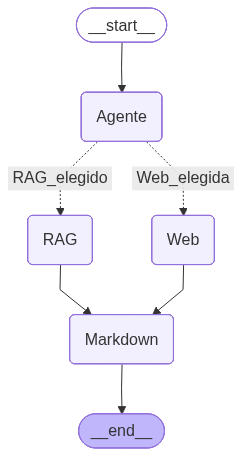

In [ ]:
from IPython.display import Image, display

imagen = agente.get_graph().draw_mermaid_png()
display(Image(imagen))

In [ ]:
def ejecutar_agente(pregunta):

  resultado = agente.invoke({
      "pregunta": pregunta,
      "fuente": "",
      "contexto": "",
      "respuesta": ""
  })

  respuesta_final = resultado["respuesta"]

  print("=" * 60)
  print(f"Fuente utilizada: {resultado["fuente"]}")
  print("=" * 60)
  print(f"Contexto utilizado: {resultado["contexto"]}")
  print("=" * 60)
  print(f"Respuesta final: {respuesta_final}")

  return respuesta_final

In [ ]:
ejecutar_agente("Dónde se mantuvo concentrado el mix de productos?")

El agente decidió la fuente RAG.
Fuente utilizada: RAG
Contexto utilizado: El mix de productos se mantuvo concentrado en circuitos combinados (Estambul + Capadocia).
Respuesta final: # Concentración del Mix de Productos

## Ubicación de la Concentración del Mix de Productos

El mix de productos se mantuvo concentrado en:

*   **Circuitos combinados**
    *   Estambul
    *   Capadocia


'# Concentración del Mix de Productos\n\n## Ubicación de la Concentración del Mix de Productos\n\nEl mix de productos se mantuvo concentrado en:\n\n*   **Circuitos combinados**\n    *   Estambul\n    *   Capadocia'

In [ ]:
ejecutar_agente("Cuántos mundiales de fútbol tiene Brasil?")

El agente decidió la fuente Web.
Fuente utilizada: Web
Contexto utilizado: ['La selección de fútbol de Brasil es la única que ha participado en todas las 22 ediciones de la Copa Mundial de Fútbol de la FIFA (habiendo sido sede en dos ...', 'Brasil es el equipo que más veces ganó la Copa Mundial de la FIFA, con cinco conquistas. Más abajo en el ranking figuran Italia y Alemania, con ...', 'Cuando BRASIL DABA MIEDO 🇧🇷 ⭐⭐⭐⭐⭐ Los 5 MUNDIALES de BRASIL La selección brasileña ha conquistado cinco Copas del Mundo y, desde hace más de 50 ...', 'Pese a sus 24 años sin títulos, Brasil sigue siendo la gran potencia en el panorama general de los Mundiales, en los que disputó 114 partidos, ...', 'La selección brasileña ha conquistado cinco Copas del Mundo y, desde hace más de 50 años presume de ser el Rey del fútbol Mundial. Pese a su ...', 'Brasil es la selección más exitosa en la historia de la Copa Mundial de Fútbol; la conquistó en cinco oportunidades (1958, 1962, 1970, 1994 y 2002)\u200b\u200b

'# La Gloriosa Trayectoria de Brasil en la Copa Mundial de Fútbol\n\nLa selección de fútbol de Brasil es, sin lugar a dudas, la nación más exitosa en la historia de la Copa Mundial de la FIFA.\n\n## Número de Títulos Mundiales\n\nBrasil ha conquistado la **Copa Mundial de la FIFA en cinco (5) ocasiones**. Esto la posiciona como la selección con más títulos en la historia del torneo.\n\n## Años de las Conquistas\n\nLas victorias de Brasil en la Copa del Mundo se distribuyen a lo largo de varias décadas, demostrando su dominio en diferentes épocas:\n\n*   **1958**\n*   **1962**\n*   **1970**\n*   **1994**\n*   **2002**\n\n## Récords y Logros Adicionales\n\nAdemás de ser el máximo ganador, Brasil ostenta otros récords impresionantes en la Copa Mundial:\n\n*   **Única nación en participar en todas las ediciones**: Brasil ha estado presente en las 22 ediciones de la Copa Mundial de la FIFA, un logro sin precedentes.\n*   **Rey del fútbol Mundial**: Pese a llevar 20 años sin ser campeón (des